In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft



In [3]:
import pandas as pd

file_path = r"C:\Users\sesa813493\Downloads\IP2X Oscillograms\SPEC26AA5693 IP2X NF Panelboard Internal Verification\112673.txt"

# Read file (tab-separated)
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    skiprows=6  # adjust if needed
)



In [4]:
df

,Time,Voltage_A,Voltage_B,Voltage_C,Current_A,Current_B,Current_C,DATA_V_A,DATA_I_A,SYNTH_A,SHFT_SYNTH_A,DATA_VA,DATA_IA
0,s,Volts,Volts,Volts,Amps,Amps,Amps,Volts,Amps,Volts,Amps,NaN,NaN
1,0,0.667208,0.191818,-0.103666,1.12916,0.41886,0.675829,0.667208,49.6482,276.313,-150.835,0.623540,1.12916
2,4E-05,0.0593069,0.124117,0.908858,-2.25832,0.41886,0.675829,0.0593069,46.2607,0,160.971,0.015639,-2.25832
3,8E-05,0.329485,0.598023,-0.306171,-2.25832,0.41886,0.675829,0.329485,46.2607,0,-170.475,0.285817,-2.25832
4,0.00012,0.26194,-0.552891,0.436347,1.12916,0.41886,0.675829,0.26194,49.6482,0,179.309,0.218273,1.12916
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12991,0.5196,0,0,0,0,0,0,0,0,0,218.859,0.000000,0.00000
12992,0.51964,0,0,0,0,0,0,0,0,0,-221.614,0.000000,0.00000
12993,0.51968,0,0,0,0,0,0,0,0,0,223.498,0.000000,0.00000
12994,0.51972,0,0,0,0,0,0,0,0,0,-224.505,0.000000,0.00000


In [5]:
VA=df["Voltage_C"][1:].to_numpy().astype(float)
VB=df["Voltage_B"][1:].to_numpy().astype(float)
VC=df["Voltage_A"][1:].to_numpy().astype(float)
IA =df["Current_C"][1:].to_numpy().astype(float)/1000
IB =df["Current_B"][1:].to_numpy().astype(float)/1000
IC =df["Current_A"][1:].to_numpy().astype(float)/1000
t=df["Time"][1:].to_numpy().astype(float)

(0.04, 0.12)

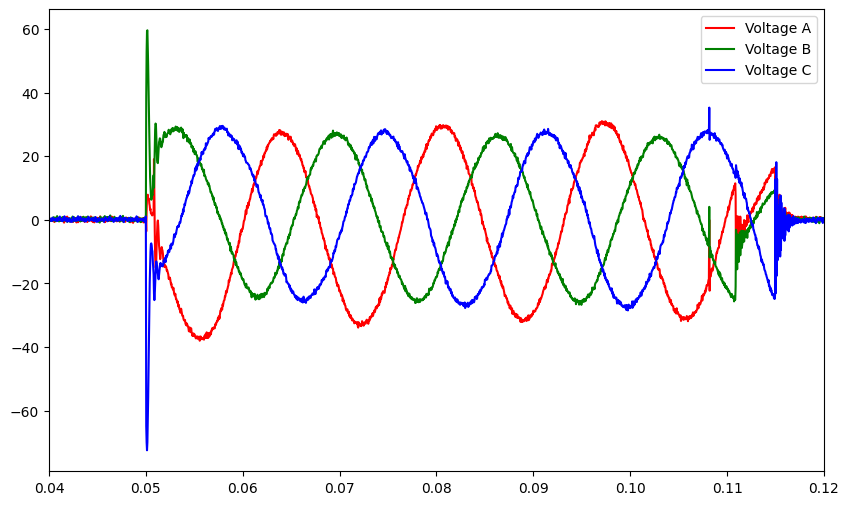

In [6]:
fig=plt.figure(figsize=(10,6))
plt.plot(t,VA,color="red")
plt.plot(t,VB,color="green")
plt.plot(t,VC,color="blue")
plt.legend(["Voltage A","Voltage B","Voltage C"])
plt.xlim((0.04,0.12))

(0.04, 0.12)

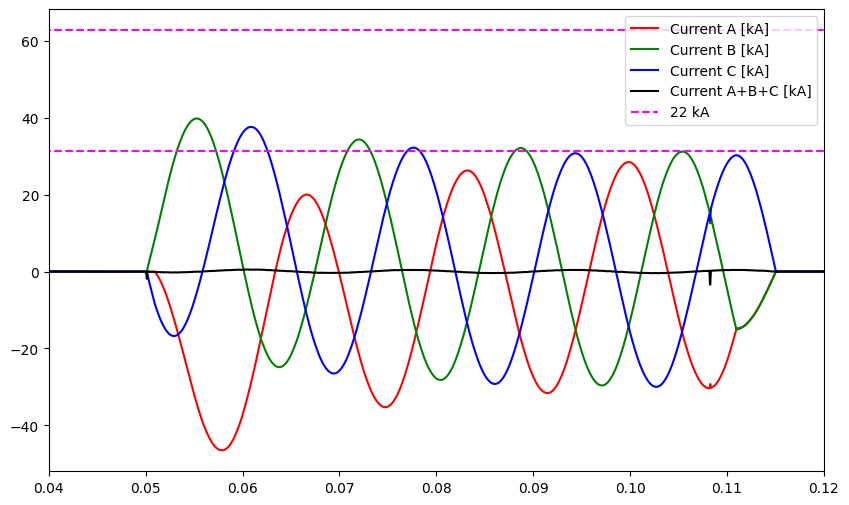

In [7]:
fig2=plt.figure(figsize=(10,6))
plt.plot(t, IA, 'r-', label="Current A [kA]")
plt.plot(t, IB, 'g-', label="Current B [kA]")
plt.plot(t, IC, 'b-', label="Current C [kA]")
plt.plot(t, IA+IB+IC, 'k-', label="Current A+B+C [kA]")
#plt.plot(t,VA,color="k",alpha=0.5)
plt.hlines([22.19*np.sqrt(2.0),22.19*np.sqrt(2.0)*2], t[0], t[-1], color="magenta", linestyle="dashed", label="22 kA")
plt.legend()
plt.legend()
plt.xlim((0.04,0.12))

(0.04, 0.12)

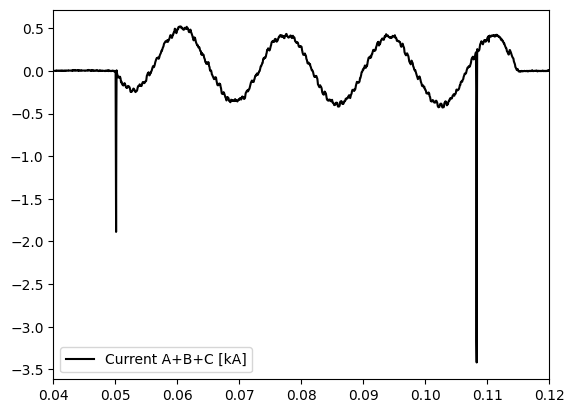

In [8]:
plt.plot(t, IA+IB+IC, 'k-', label="Current A+B+C [kA]")
plt.legend()
plt.xlim((0.04,0.12))


(-180.0, 180.0)

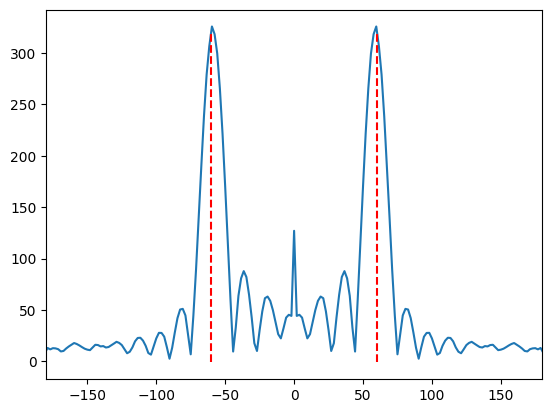

In [9]:
F=np.fft.fftshift(fft(IA+IB+IC))
fftfreq = np.fft.fftshift(np.fft.fftfreq(len(t), d=(t[1]-t[0])))
plt.plot(fftfreq,np.abs(F))
plt.vlines([-60,60], -1,320, color="red", linestyle="dashed")
plt.xlim((-3*60,60*3))


(-60.0, 60.0)

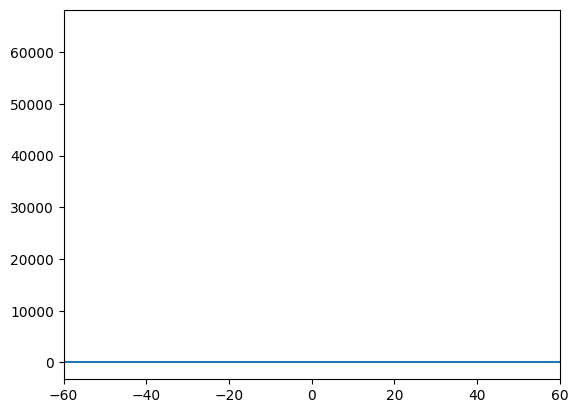

In [10]:
sig=10*np.sin(2*np.pi*50*t)
plt.plot(fftfreq,np.abs(fft(sig)))
plt.xlim((-60,60))

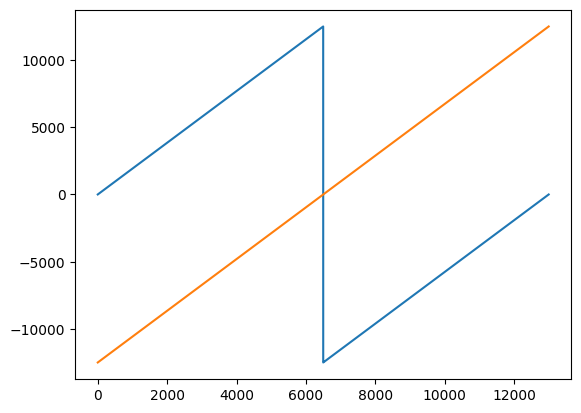

In [11]:
fftshift = np.fft.fftshift(fftfreq)
plt.plot(fftshift)
plt.plot(fftfreq)

In [12]:
PF=17/100
pp=2*np.pi/3
pp2=np.pi #align with experimental data angle
phi=np.arccos(PF)
I_0=22.19*np.sqrt(2)
w=2*np.pi*60
IAp=I_0 *(np.sin(w*t-phi-pp2)-np.sin(-phi+pp2)*np.exp(-(w*t/np.tan(phi))))
IBp=I_0 *(np.sin(w*t-phi-pp-pp2)-np.sin(-phi-pp+pp2)*np.exp(-(w*t/np.tan(phi))))
ICp=I_0 *(np.sin(w*t-phi+pp+pp2)-np.sin(-phi+pp+pp2)*np.exp(-(w*t/np.tan(phi))))

Text(0, 0.5, 'Current [kA]')

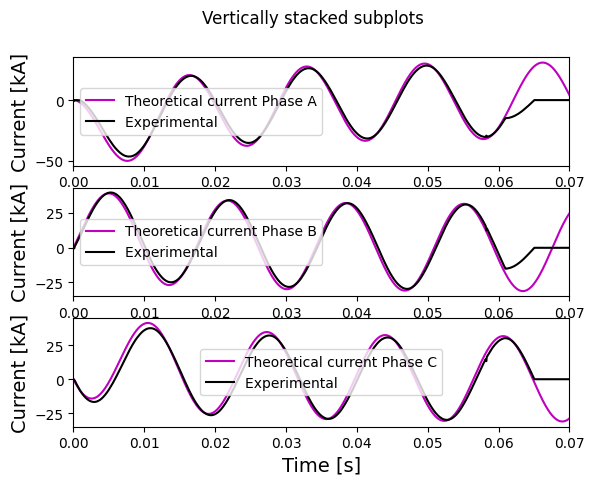

In [13]:
fig, axs = plt.subplots(3)
dd=0.05 ###Shift experimental data to align with 0 
fig.suptitle('Vertically stacked subplots')
axs[0].plot(t,IAp, 'm-',label="Theoretical current Phase A")
axs[0].plot(t-dd,IA,color="k",label="Experimental ")
axs[0].legend()
axs[0].set_xlim((0,0.07))
axs[0].set_xlabel("Time [s]",fontsize=14)
axs[0].set_ylabel("Current [kA]",fontsize=14)

axs[1].plot(t,IBp, 'm-',label="Theoretical current Phase B")
axs[1].plot(t-dd,IB,color="k",label="Experimental ")
axs[1].legend()
axs[1].set_xlim((0,0.07))
axs[1].set_xlabel("Time [s]",fontsize=14)
axs[1].set_ylabel("Current [kA]",fontsize=14)

axs[2].plot(t,ICp, 'm-',label="Theoretical current Phase C")
axs[2].plot(t-dd,IC,color="k",label="Experimental ")
axs[2].legend()
axs[2].set_xlim((0,0.07))
axs[2].set_xlabel("Time [s]",fontsize=14)
axs[2].set_ylabel("Current [kA]",fontsize=14)


(0.0, 0.07)

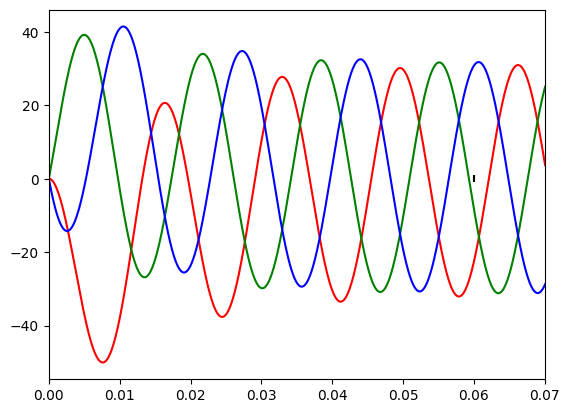

In [14]:
plt.plot(t,IAp, 'r-',label="Theoretical current Phase A")
#plt.plot(t, VA)
plt.plot(t,IBp, 'g-',label="Theoretical current Phase B")
plt.plot(t,ICp, 'b-',label="Theoretical current Phase C")
plt.vlines([0.06], -1,1, color="k", linestyle="dashed", label="Shifted 0")
plt.xlim((0,0.07))


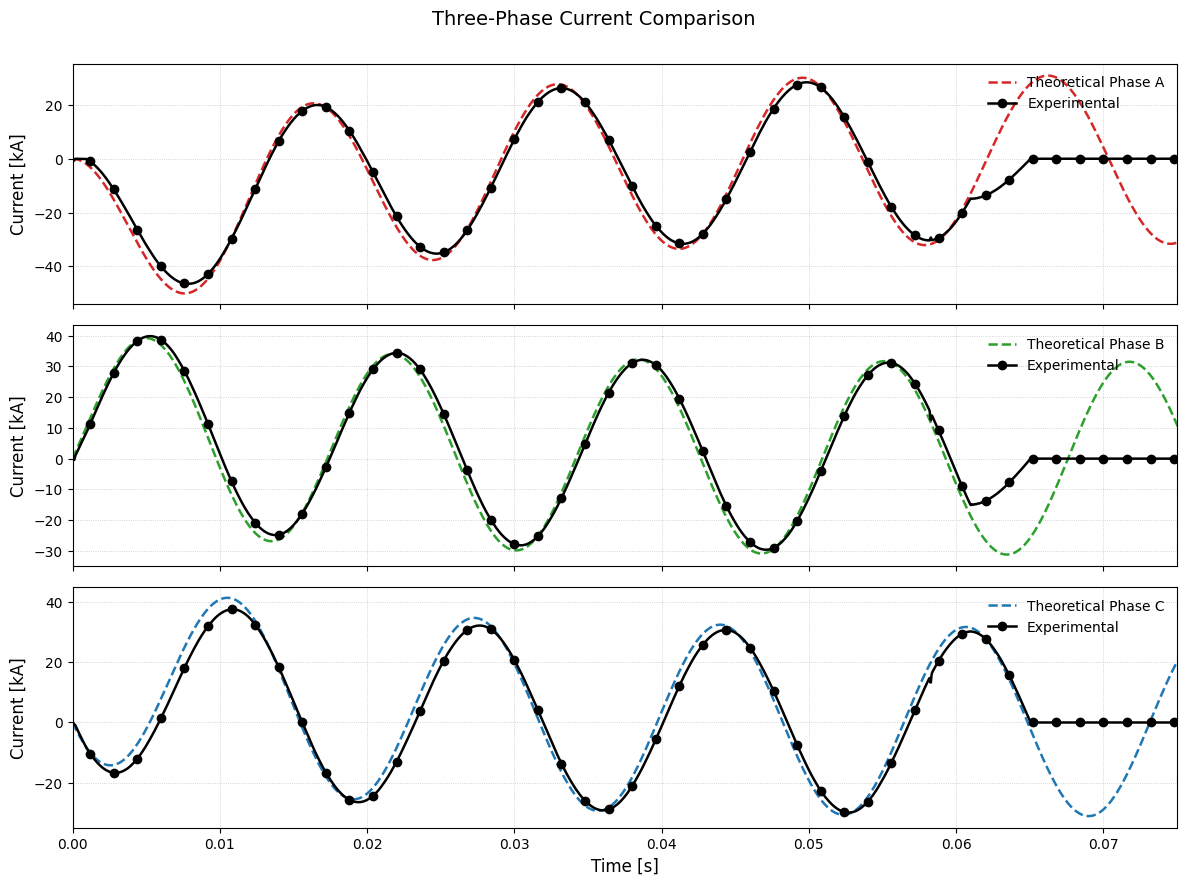

In [15]:

# Global style tuning (article-like)
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.8,
})

fig, axs = plt.subplots(3, sharex=True, figsize=(12,9))
fig.suptitle('Three-Phase Current Comparison', fontsize=14)

# Color palette (consistent across phases)
colors = ["tab:red", "tab:green", "tab:blue"]

data = [
    (IAp, IA, "Phase A"),
    (IBp, IB, "Phase B"),
    (ICp, IC, "Phase C"),
]

for i, (theo, exp, label) in enumerate(data):
    axs[i].plot(t, theo, linestyle='--', color=colors[i], label=f"Theoretical {label}")
    axs[i].plot(t - dd, exp, linestyle='-',marker='o', markersize=6, color='black', label="Experimental",markevery=40,)

    axs[i].set_ylabel("Current [kA]")
    axs[i].set_xlim(0, 0.075)

    # Subtle grid (important for publications)
    axs[i].grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.7)

    # Clean legend placement
    axs[i].legend(loc="upper right", frameon=False)

# Only bottom subplot gets x-label
axs[-1].set_xlabel("Time [s]")

# Improve spacing
plt.tight_layout()
plt.subplots_adjust(top=0.92)

plt.show()

(0.04, 0.12)

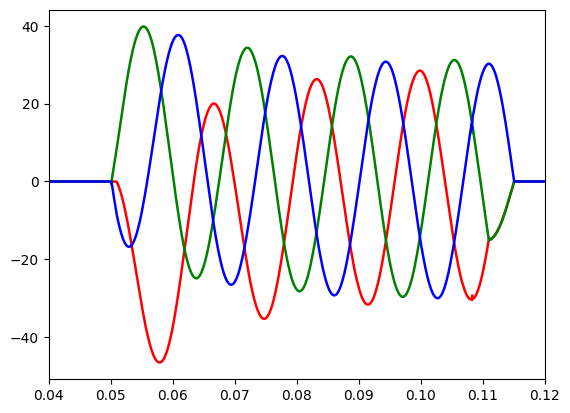

In [16]:
plt.plot(t,IA,color="red")
plt.plot(t,IB,color="green")
plt.plot(t,IC,color="blue")
plt.xlim((0.04,0.12))

In [17]:
plt.savefig(
    "three_phase_currents.png",
    format="png",
    bbox_inches="tight",
    transparent=True  # useful for papers/presentations
)

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Time [s]')

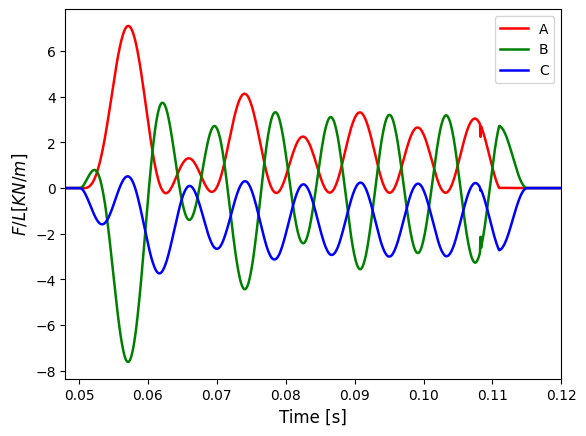

In [19]:
#Magnetic Force
mu0=4*np.pi*1e-7
k=mu0/(2*np.pi)
d=0.05
xa=d
xb= 0
xc= -d

fA=-k*IA*(IB/(xa-xb)+IC/(xa-xc))
fB=-k*IB*(IA/(xb-xa)+IC/(xb-xc))
fC=-k*IC*(IA/(xc-xa)+IB/(xc-xb))
plt.plot(t,fA*1000, color="red", label="A")
plt.plot(t,fB*1000, color ="green",label="B")
plt.plot(t,fC*1000, color ="blue", label="C")
plt.legend()
plt.xlim((0.048,0.12))
plt.ylabel("$F/L [KN/m]$")
plt.xlabel("Time [s]")